In [ ]:
#imported from Pranav Sanghavi's notebook -- 
import glob 
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
from rawice import *
import math
import psutil
import matplotlib.cm as cm
#importing for Will's function --  
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable

style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()


In [ ]:
print("current python version is:",python_version())
print("current numpy version is:",np.__version__)

In [ ]:
"""
    Reading digital gains for all the correlator channels 
"""

f = h5py.File("/Users/kalyanibhopi94/Documents/iceboard_data/digital_gains/20250319T171034Z_WVUc52_digitalgain/00000057.h5","r")

#Plotting digital gains -- 
print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))
print((f['compute_time']))
print((f['index_map']))
print((f['gain_coeff']))
print((f['gain_exp']))

inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()

## Analysing raw adc rms of the whole data run; Plotting Histogram of the signal received per correlator channel; From Pranav's "analyse_raw_adc-checkpoint.ipynb" notebook ##

In [ ]:
folder_path = "/Users/kalyanibhopi94/Downloads/iceboard_data/corr_data/20250609T180246Z_WVUc52/raw_acq/"
try:
    file_name = get_newest_file(folder_path)
    raw_acq(file_name, False)
except OSError:
    file_name = get_second_newest_file(folder_path)
    raw_acq(file_name, False)

In [ ]:
crate_number = 0 
slot_number = 0

figrms = plt.figure(figsize=(30, 30))
figfft = plt.figure(figsize=(30, 30))
fighist = plt.figure(figsize=(30, 30))

figrms.suptitle(f"ADC RMS START: {raw_acq.start_time} STOP: {raw_acq.end_time}\n crate no.:{crate_number} slot no.:{crate_number}", y=0.92,
ha='center')
figfft.suptitle(f"FFT MAG START: {raw_acq.start_time} STOP:{raw_acq.end_time} \n crate no.:{crate_number} slot no.:{crate_number}", y=0.92,
ha='center')
fighist.suptitle(f"ADC Histogram START: {raw_acq.start_time} STOP:{raw_acq.end_time} \n crate no.:{crate_number} slot no.:{crate_number} ", y=0.92,
ha='center')


rms_above_threshold = {}
rms_below_threshold = {}

for i in range(4):
    input_to_check = [crate_number, slot_number, i]
    raw = raw_acq.check_input(input_to_check)
    rms = raw.rms
    if np.median(rms) > 60:
        rms_above_threshold[i] = "ADC RMS above 60"
    if np.median(rms) < 8:
        rms_below_threshold[i] = "ADC RMS below 8"
    fft = raw.mag_fft
    ts = raw.time_fpga_count
    times = (ts - ts[0])*2.56e-6/60
    axrms = figrms.add_subplot(4, 4, i+1)
    axrms.scatter(times, rms, s=1, c='k', rasterized=True)
    axrms.set_title(f'input: {i}')
    axrms.set_xlabel('minutes')
    axrms.set_ylabel('adc units')
    axrms.axhline([2], lw=0.5, c='r')
    axrms.grid(axis='both', linestyle='-', linewidth=1)
    
    axfft = figfft.add_subplot(4, 4, i+1)
    axfft.imshow(
        fft,
        aspect='auto',
        vmin=np.percentile(fft, 5),
        vmax=np.percentile(fft, 95),
        extent=[800, 400, times[-1], times[0]],
        interpolation='none',
        rasterized=True
    )
    axfft.set_title(f'input: {i}')
    axfft.set_ylabel("minutes")
    axfft.set_xlabel("MHz")
    
    inp0 = np.where(raw_acq.adc_input[:] == i)[0]
    ant0_data = raw_acq.timestream[:][inp0]
    ant0_data = ant0_data[:]
    axhist = fighist.add_subplot(4, 4, i+1)
    hist, bin_edges = np.histogram(ant0_data, bins=256,  density=True)
    axhist.step(bin_edges[1:], hist, where='mid', c='k', rasterized=True)
    axhist.set_title(f'input: {i}')
    axhist.set_xlim([-129, 129])
    axhist.set_ylim(0,0.1)
    
#pp = PdfPages(f"{SAVE_DIR}{raw_acq.start_time}_{raw_acq.end_time}_raw_acq.pdf")
#pp.savefig(figrms)
#pp.savefig(figfft)
#pp.savefig(fighist)
#pp.close()

## Analysis of correlator data for correlation powers, waterfall and phase ##

In [2]:
## temporary snippet for publication figures -- 

file_path = '/Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/*/*' 
corr_data100p = read_corr_mode_h5(file_path, f_start=254, f_stop=257)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag100p, pow_phase100p = get_mag_phase(corr_data100p.vis)
print("done getting pow_mag and pow_phase")
corr_size100p=corr_data100p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size100p)) # time bins - freq bins - corr indices

corr_data115p = read_corr_mode_h5(file_path, f_start=269, f_stop=272)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag115p, pow_phase115p = get_mag_phase(corr_data115p.vis)
print("done getting pow_mag and pow_phase")
corr_size115p=corr_data115p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size115p)) # time bins - freq bins - corr indices

corr_data130p = read_corr_mode_h5(file_path, f_start=284, f_stop=287)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag130p, pow_phase130p = get_mag_phase(corr_data130p.vis)
print("done getting pow_mag and pow_phase")
corr_size130p=corr_data130p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size130p)) # time bins - freq bins - corr indices



Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0254
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0254
Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0255
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0255
Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0256
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0256
Done!!!!!!!
getting auto and cross-correlation magnitudes and phase
done getting pow_mag and pow_phase
corr data shape: (768, 1024, 10)
Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/cor

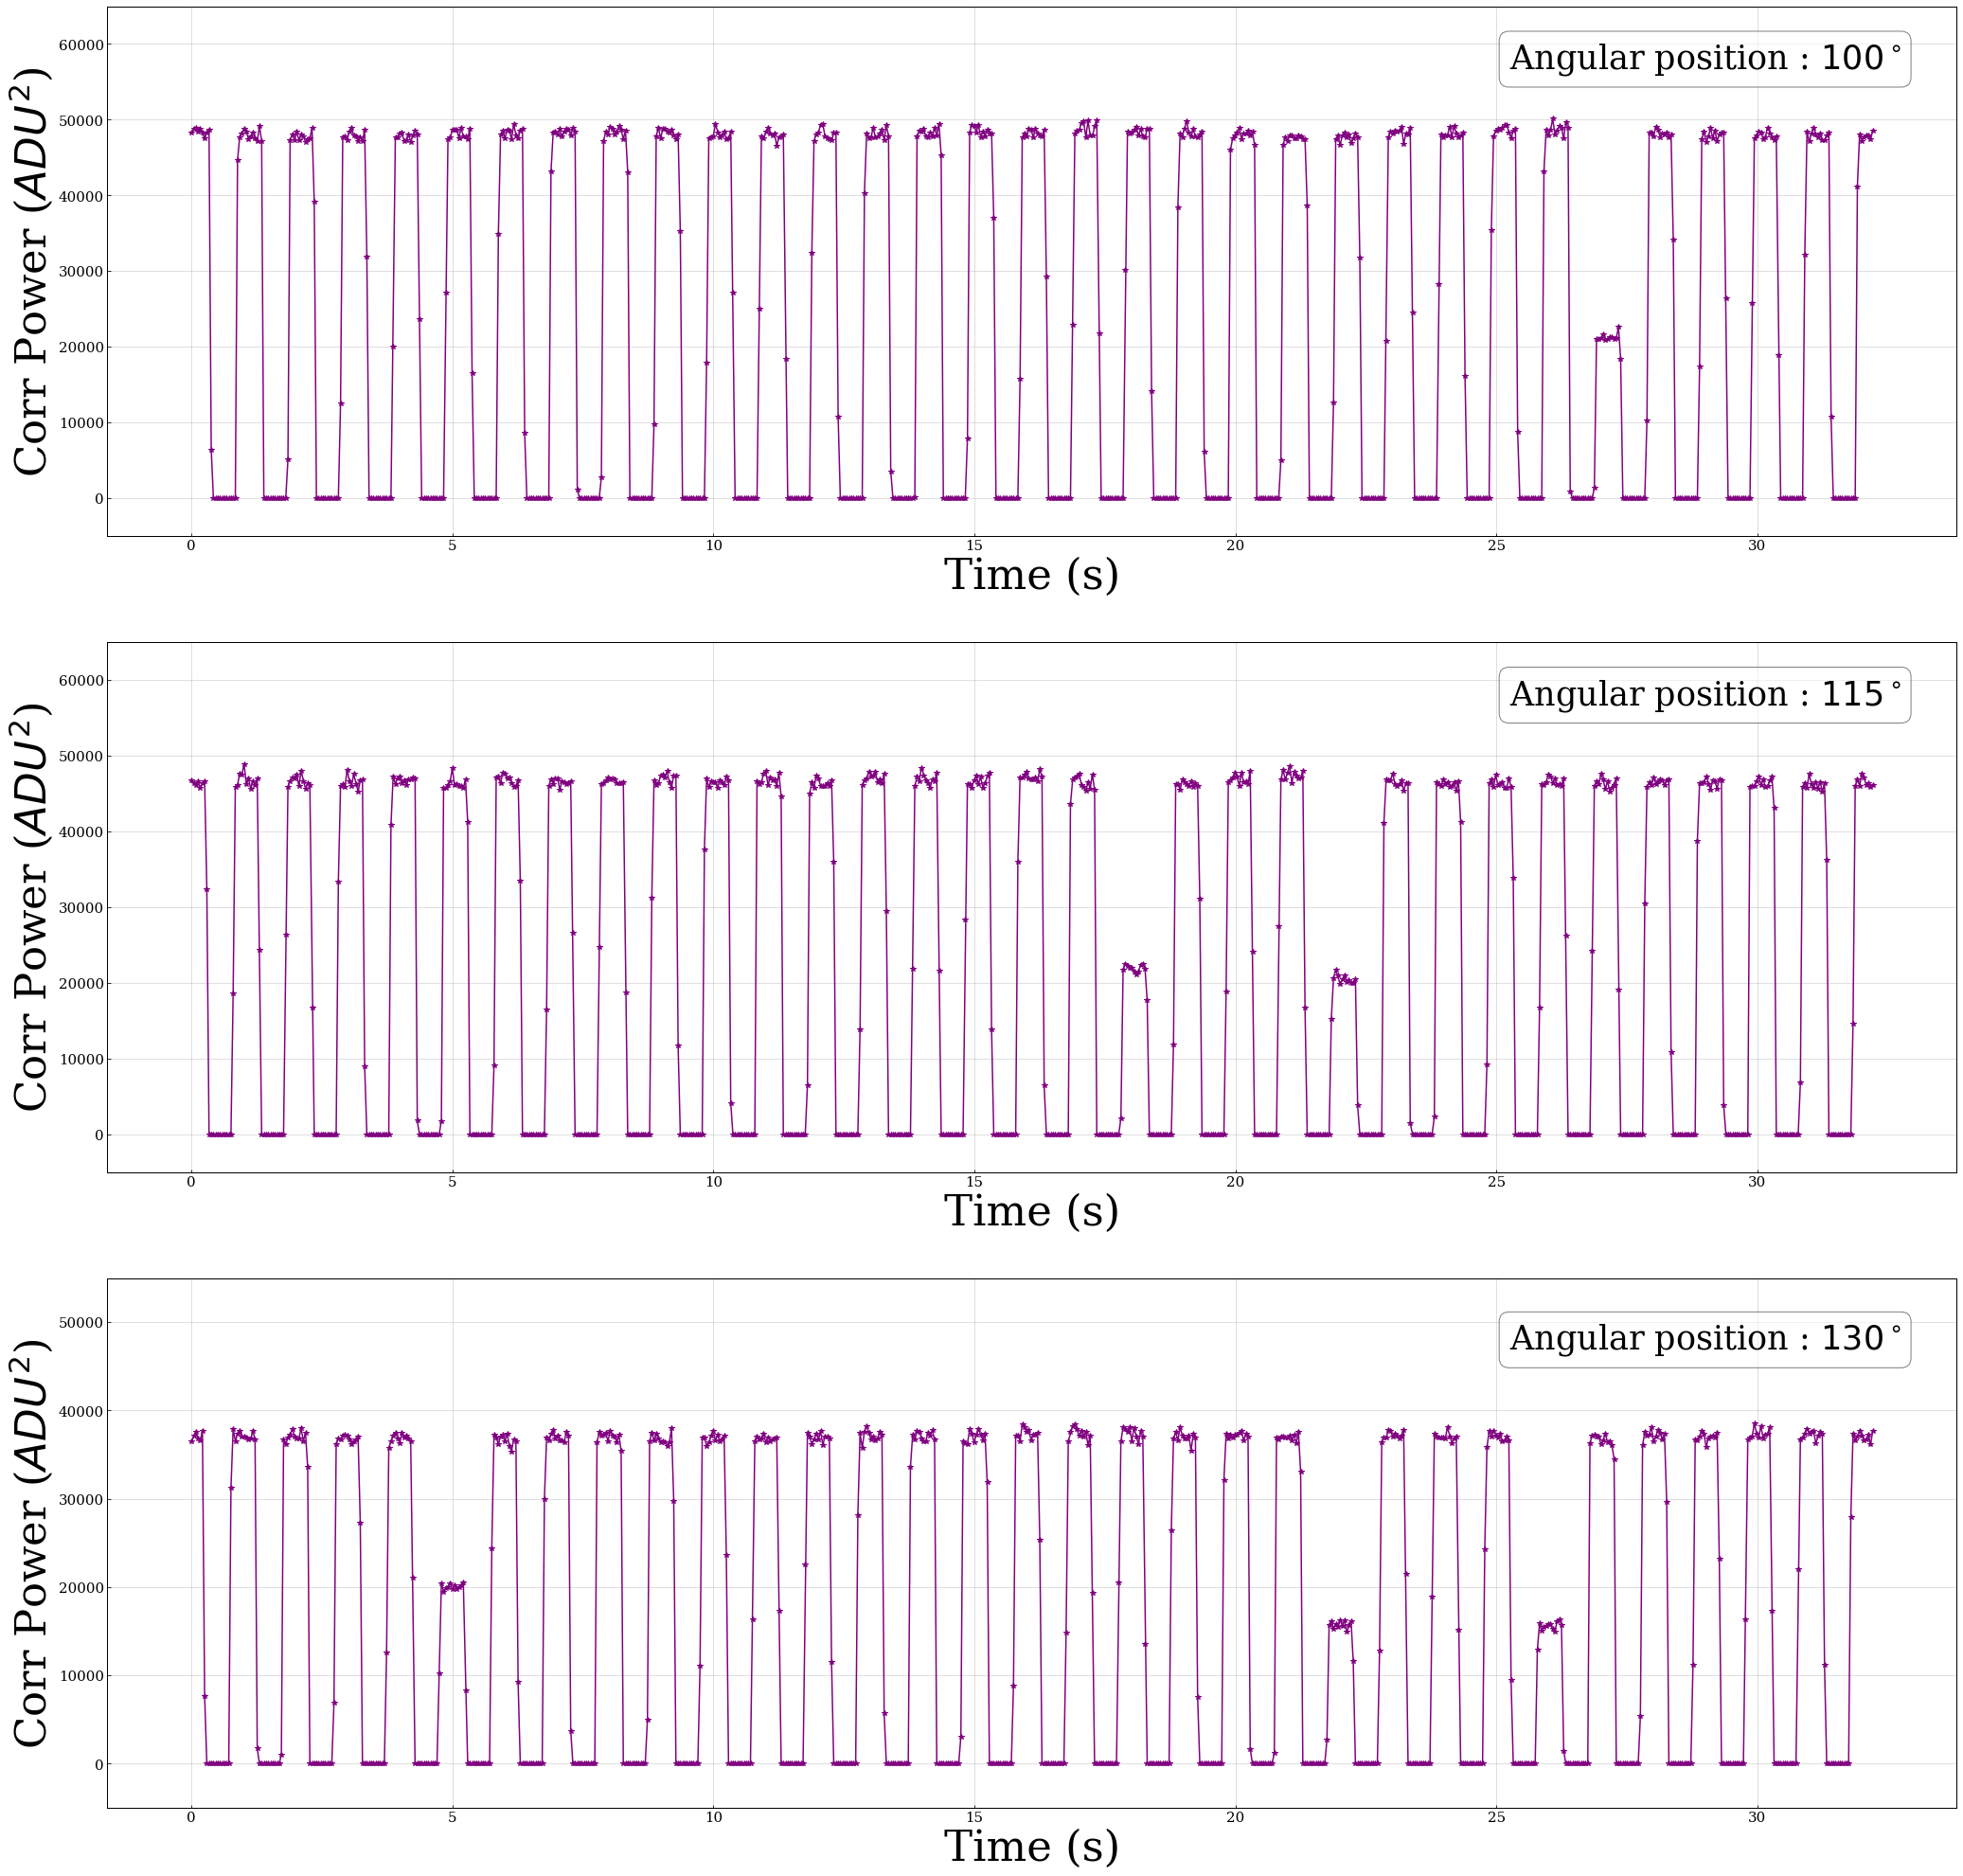

In [7]:
## temporary for publication figures --

corr_size100p=corr_data100p.vis[:,:,:].shape
delta_time = np.diff(corr_data100p.time["irigb_time"])[1]*1e-9

tmin,tmax=[0,corr_size100p[0]] #time in t-indices
xtime=np.linspace(0,delta_time*tmax, tmax) # time in seconds 
f_ind=850
corr_index=1
    
colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(35, 35))
freq=400+((1024-f_ind)*0.390625)

ax1.plot(xtime,pow_mag100p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax1.text(29, 58000, r"Angular position : $100^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax1.set_xlabel("Time (s)", fontsize=45)
ax1.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax1.set_ylim(-5000,65000)
ax2.plot(xtime,pow_mag115p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax2.text(29, 58000, r"Angular position : $115^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax2.set_xlabel("Time (s)", fontsize=45)
ax2.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax2.set_ylim(-5000,65000)
ax3.plot(xtime,pow_mag130p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax3.text(29, 48000, r"Angular position : $130^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax3.set_xlabel("Time (s)", fontsize=45)
ax3.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax3.set_ylim(-5000,55000)

plt.show()
plt.tight_layout()

#fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/publication_figures/chamber_corr_powers_glitches_higherangles.pdf', 
#            dpi=300)

In [8]:
#Reading correlation files -- 
file_path = '/Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/*/*' 
corr_data = read_corr_mode_h5(file_path, f_start=254, f_stop=257) 
print("getting auto and cross-correlation magnitudes and phase")
pow_mag, pow_phase = get_mag_phase(corr_data.vis)
print("done getting pow_mag and pow_phase")
sat_data = corr_data.sat.real

corr_size=corr_data.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size)) # time bins - freq bins - corr indices

Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0254
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0254
Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0255
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0255
Reading File: /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0256
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0256
Done!!!!!!!
getting auto and cross-correlation magnitudes and phase
done getting pow_mag and pow_phase
corr data shape: (768, 1024, 10)


Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 768
lowest time bin 0 and highest time bin 768
32.212254720000004 seconds of data (considered for the plots)


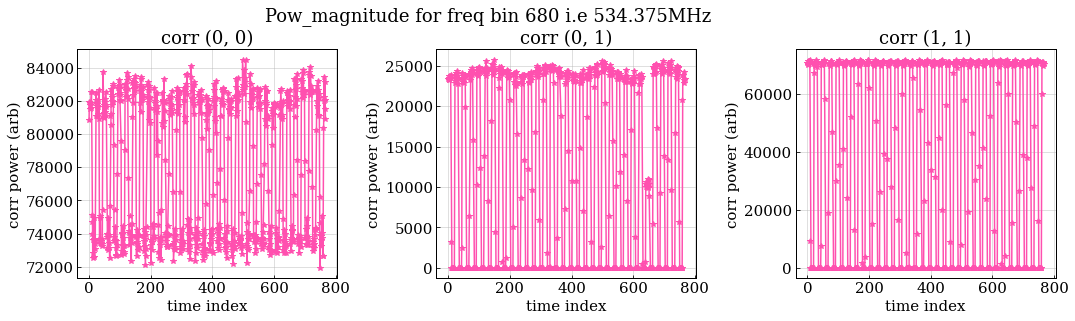

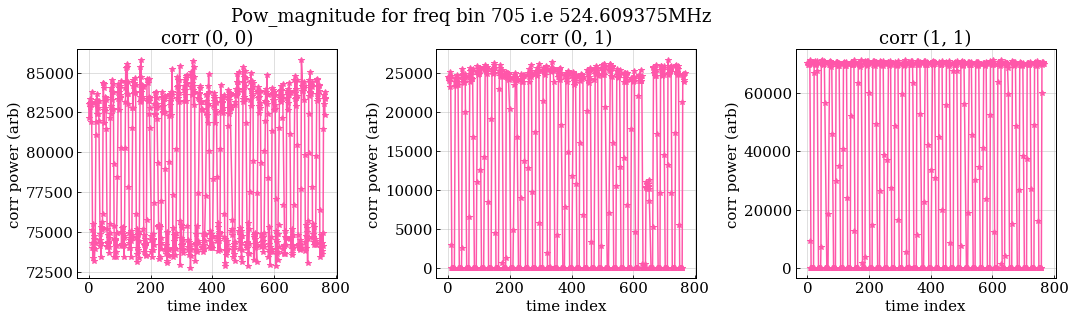

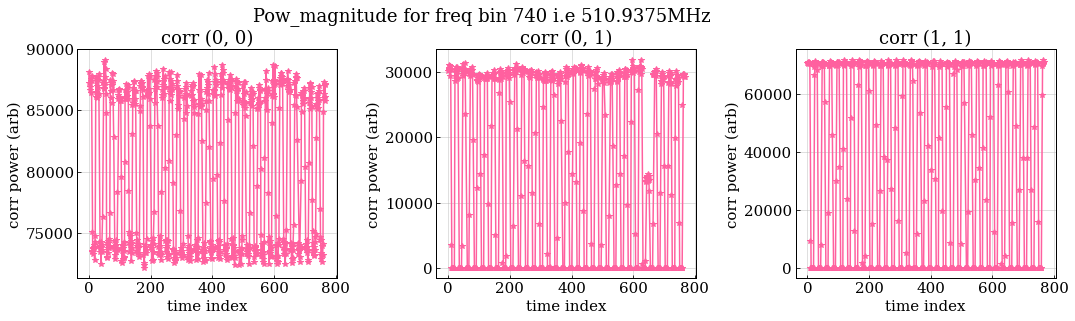

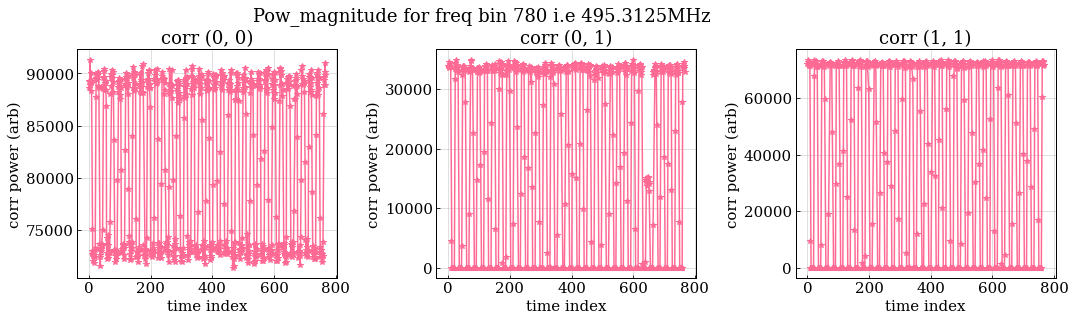

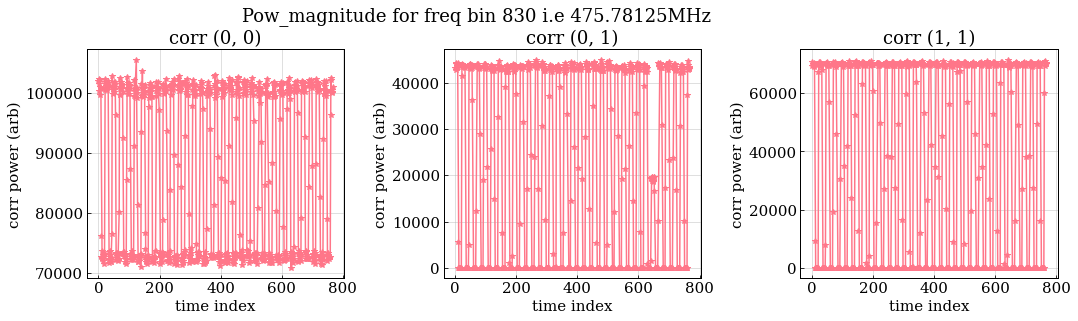

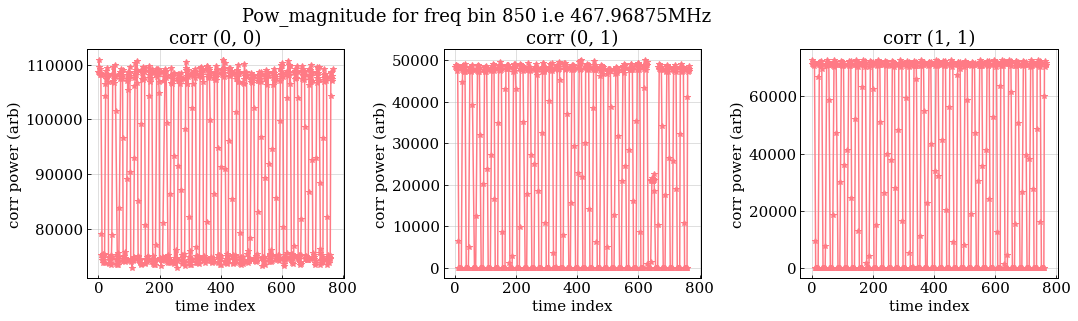

In [11]:
#Plotting correlation powers against time index for a given set of frequencies -- 
tmin,tmax=[0,corr_size[0]]
freq_arr=[680,705,740,780,830,850]
corr_indices=[0,1,4]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[20,20])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(pow_mag[tmin:tmax,f_ind,corr_index], marker="*", c=colorsarr[f_ind+500])
        #plt.ylim(0,120000)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='right')
    plt.tight_layout()

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}")
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)")

In [ ]:
#Plotting waterfall --
corr_indices=[0,1,4] 
plot_waterfall_corr_data(pow_mag[:,:,:],corr_indices)

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_2675/3786300071.py:140: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar=fig.colorbar(im,cax=cax)


In [ ]:
#Phase for a set of time indices as a function of frequency:

t_ind_arr= [100,200,270,360,415,509]
corr_indices=[0,1,4]
plot_phase_corr_data(pow_phase[:,:,:], corr_indices, t_ind_arr)

In [ ]:
# plotting single time bin across the 400-800MHz band 

colorsarr=cm.inferno(np.linspace(0,1,1024))
plt.figure(figsize=[15,20])
k=100
tb_on=415
tb_off=425

freq_arr=[70,195,250,280,330,380,460,515,545,600,640,680,705,740,780,830,850]
plt.subplot(2,1,1)
plt.plot(pow_mag[tb_on,:,0], c=colorsarr[k], label='Cal signal ON') 
plt.plot(pow_mag[tb_off,:,0], c=colorsarr[k+600], label='System noise')
#plt.xlim(300,500)
plt.title("time bin {} (on) and {} (off) -- 0x0".format(tb_on, tb_off))
plt.xlabel('frequency index')
plt.ylabel('corr powers ($adu^2$)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--')
    x=freq
    plt.text(
    x, 20000, f'Freq ind = {freq}', rotation=90,
    #transform=ax.get_yaxis_transform(), 
    ha='right', va='bottom', fontsize=15,
    color='r'
)
#plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
plt.legend(loc='lower left', bbox_to_anchor=(0.81, 0.02))

plt.subplot(2,1,2)
plt.plot(pow_mag[tb_on,:,4], c=colorsarr[k], label='ref sig ON')
plt.plot(pow_mag[tb_off,:,4], c=colorsarr[k+600], label='ref signal OFF')
#plt.xlim(0,500)
plt.title("time bin {} (on) and {} (off) --1x1".format(tb_on, tb_off))
plt.xlabel('frequency index')
plt.ylabel('corr powers ($adu^2$)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--')
    x=freq
    plt.text(
    x, 1000, f'Freq ind = {freq}', rotation=90,
    #transform=ax.get_yaxis_transform(), 
    ha='right', va='bottom', fontsize=15,
    color='r'
)
#plt.axhline(50000, color='r', linestyle='--', linewidth=2, label='50000')
#plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
plt.legend(loc='lower left', bbox_to_anchor=(0.81, 0.05))

#plt.suptitle(f"freq spectrum of single time index")
plt.tight_layout()

plt.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/freq_spec_tbin{tb_on}and{tb_off}.pdf', dpi=300)



### Saving Statistics  ###

In [ ]:
## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Users/kalyanibhopi94/Documents/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/*/*' 

# reading files for 0 degrees angle between rx and tx
corr_data0 = read_corr_mode_h5(file_path, f_start=152, f_stop=154)
pow_mag0, pow_phase0 = get_mag_phase(corr_data0.vis)
# reading files for negative 5 degrees angle between rx and tx
corr_data5n = read_corr_mode_h5(file_path, f_start=146, f_stop=149)
pow_mag5n, pow_phase5n = get_mag_phase(corr_data5n.vis)
# reading files for negative 10 degrees angle between rx and tx
corr_data10n = read_corr_mode_h5(file_path, f_start=141, f_stop=144)
pow_mag10n, pow_phase10n = get_mag_phase(corr_data10n.vis)
# reading files for negative 15 degrees angle between rx and tx
corr_data15n = read_corr_mode_h5(file_path, f_start=136, f_stop=139)
pow_mag15n, pow_phase15n = get_mag_phase(corr_data15n.vis)
# reading files for negative 20 degrees angle between rx and tx
corr_data20n = read_corr_mode_h5(file_path, f_start=131, f_stop=134)
pow_mag20n, pow_phase20n = get_mag_phase(corr_data20n.vis)
# reading files for negative 25 degrees angle between rx and tx
corr_data25n = read_corr_mode_h5(file_path, f_start=126, f_stop=129)
pow_mag25n, pow_phase25n = get_mag_phase(corr_data25n.vis)
# reading files for negative 30 degrees angle between rx and tx
corr_data30n = read_corr_mode_h5(file_path, f_start=121, f_stop=124)
pow_mag30n, pow_phase30n = get_mag_phase(corr_data30n.vis)
# reading files for negative 35 degrees angle between rx and tx
corr_data35n = read_corr_mode_h5(file_path, f_start=116, f_stop=119)
pow_mag35n, pow_phase35n = get_mag_phase(corr_data35n.vis)
# reading files for negative 40 degrees angle between rx and tx
corr_data40n = read_corr_mode_h5(file_path, f_start=111, f_stop=114)
pow_mag40n, pow_phase40n = get_mag_phase(corr_data40n.vis)
# reading files for negative 45 degrees angle between rx and tx
corr_data45n = read_corr_mode_h5(file_path, f_start=106, f_stop=109)
pow_mag45n, pow_phase45n = get_mag_phase(corr_data45n.vis)
# reading files for negative 50 degrees angle between rx and tx
corr_data50n = read_corr_mode_h5(file_path, f_start=100, f_stop=103)
pow_mag50n, pow_phase50n = get_mag_phase(corr_data50n.vis)
# reading files for negative 55 degrees angle between rx and tx
#corr_data55n = read_corr_mode_h5(file_path, f_start=139, f_stop=142)
#pow_mag55n, pow_phase55n = get_mag_phase(corr_data55n.vis)
# reading files for negative 60 degrees angle between rx and tx
#corr_data60n = read_corr_mode_h5(file_path, f_start=143, f_stop=146)
#pow_mag60n, pow_phase60n = get_mag_phase(corr_data60n.vis)
# reading files for negative 65 degrees angle between rx and tx
#corr_data65n = read_corr_mode_h5(file_path, f_start=148, f_stop=151)
#pow_mag65n, pow_phase65n = get_mag_phase(corr_data65n.vis)
# reading files for negative 70 degrees angle between rx and tx
#corr_data70n = read_corr_mode_h5(file_path, f_start=153, f_stop=156)
#pow_mag70n, pow_phase70n = get_mag_phase(corr_data70n.vis)
# reading files for negative 75 degrees angle between rx and tx
#corr_data75n = read_corr_mode_h5(file_path, f_start=158, f_stop=161)
#pow_mag75n, pow_phase75n = get_mag_phase(corr_data75n.vis)
# reading files for negative 80 degrees angle between rx and tx 
#corr_data80n = read_corr_mode_h5(file_path, f_start=164, f_stop=167)
#pow_mag80n, pow_phase80n = get_mag_phase(corr_data80n.vis)
# reading files for negative 85 degrees angle between rx and tx 
#corr_data85n = read_corr_mode_h5(file_path, f_start=171, f_stop=174)
#pow_mag85n, pow_phase85n = get_mag_phase(corr_data85n.vis)
# reading files for negative 90 degrees angle between rx and tx 
#corr_data90n = read_corr_mode_h5(file_path, f_start=176, f_stop=179)
#pow_mag90n, pow_phase90n = get_mag_phase(corr_data90n.vis)
# reading files for negative 95 degrees angle between rx and tx 
#corr_data95n = read_corr_mode_h5(file_path, f_start=181, f_stop=184)
#pow_mag95n, pow_phase95n = get_mag_phase(corr_data95n.vis)
# reading files for negative 100 degrees angle between rx and tx 
#corr_data100n = read_corr_mode_h5(file_path, f_start=186, f_stop=189)
#pow_mag100n, pow_phase100n = get_mag_phase(corr_data100n.vis)
# reading files for negative 105 degrees angle between rx and tx 
#corr_data105n = read_corr_mode_h5(file_path, f_start=191, f_stop=194)
#pow_mag105n, pow_phase105n = get_mag_phase(corr_data105n.vis)
# reading files for negative 110 degrees angle between rx and tx 
#corr_data110n = read_corr_mode_h5(file_path, f_start=197, f_stop=200)
#pow_mag110n, pow_phase110n = get_mag_phase(corr_data110n.vis)
# reading files for negative 115 degrees angle between rx and tx 
#corr_data115n = read_corr_mode_h5(file_path, f_start=202, f_stop=205)
#pow_mag115n, pow_phase115n = get_mag_phase(corr_data115n.vis)
# reading files for negative 120 degrees angle between rx and tx 
#corr_data120n = read_corr_mode_h5(file_path, f_start=207, f_stop=210)
#pow_mag120n, pow_phase120n = get_mag_phase(corr_data120n.vis)
# reading files for negative 125 degrees angle between rx and tx 
#corr_data125n = read_corr_mode_h5(file_path, f_start=213, f_stop=216)
#pow_mag125n, pow_phase125n = get_mag_phase(corr_data125n.vis)
# reading files for negative 130 degrees angle between rx and tx 
#corr_data130n = read_corr_mode_h5(file_path, f_start=219, f_stop=222)
#pow_mag130n, pow_phase130n = get_mag_phase(corr_data130n.vis)

# reading files for positive 5 degrees angle between rx and tx
corr_data5p = read_corr_mode_h5(file_path, f_start=156, f_stop=159)
pow_mag5p, pow_phase5p = get_mag_phase(corr_data5p.vis)
# reading files for positive 10 degrees angle between rx and tx
corr_data10p = read_corr_mode_h5(file_path, f_start=161, f_stop=164)
pow_mag10p, pow_phase10p = get_mag_phase(corr_data10p.vis)
# reading files for positive 15 degrees angle between rx and tx
corr_data15p = read_corr_mode_h5(file_path, f_start=167, f_stop=170)
pow_mag15p, pow_phase15p = get_mag_phase(corr_data15p.vis)
# reading files for positive 20 degrees angle between rx and tx 
corr_data20p = read_corr_mode_h5(file_path, f_start=172, f_stop=175)
pow_mag20p, pow_phase20p = get_mag_phase(corr_data20p.vis)
# reading files for positive 25 degrees angle between rx and tx 
corr_data25p = read_corr_mode_h5(file_path, f_start=178, f_stop=181)
pow_mag25p, pow_phase25p = get_mag_phase(corr_data25p.vis)
# reading files for positive 30 degrees angle between rx and tx
corr_data30p = read_corr_mode_h5(file_path, f_start=184, f_stop=187)
pow_mag30p, pow_phase30p = get_mag_phase(corr_data30p.vis)
# reading files for positive 35 degrees angle between rx and tx
corr_data35p = read_corr_mode_h5(file_path, f_start=189, f_stop=192)
pow_mag35p, pow_phase35p = get_mag_phase(corr_data35p.vis)
# reading files for positive 40 degrees angle between rx and tx 
corr_data40p = read_corr_mode_h5(file_path, f_start=194, f_stop=197)
pow_mag40p, pow_phase40p = get_mag_phase(corr_data40p.vis)
# reading files for positive 45 degrees angle between rx and tx 
corr_data45p = read_corr_mode_h5(file_path, f_start=199, f_stop=202)
pow_mag45p, pow_phase45p = get_mag_phase(corr_data45p.vis)
# reading files for positive 50 degrees angle between rx and tx
corr_data50p = read_corr_mode_h5(file_path, f_start=204, f_stop=207)
pow_mag50p, pow_phase50p = get_mag_phase(corr_data50p.vis)
# reading files for positive 55 degrees angle between rx and tx
corr_data55p = read_corr_mode_h5(file_path, f_start=209, f_stop=212)
pow_mag55p, pow_phase55p = get_mag_phase(corr_data55p.vis)
# reading files for positive 60 degrees angle between rx and tx 
corr_data60p = read_corr_mode_h5(file_path, f_start=214, f_stop=217)
pow_mag60p, pow_phase60p = get_mag_phase(corr_data60p.vis)
# reading files for positive 65 degrees angle between rx and tx 
corr_data65p = read_corr_mode_h5(file_path, f_start=219, f_stop=222)
pow_mag65p, pow_phase65p = get_mag_phase(corr_data65p.vis)
# reading files for positive 70 degrees angle between rx and tx
corr_data70p = read_corr_mode_h5(file_path, f_start=224, f_stop=227)
pow_mag70p, pow_phase70p = get_mag_phase(corr_data70p.vis)
# reading files for positive 75 degrees angle between rx and tx
corr_data75p = read_corr_mode_h5(file_path, f_start=229, f_stop=232)
pow_mag75p, pow_phase75p = get_mag_phase(corr_data75p.vis)
# reading files for positive 80 degrees angle between rx and tx 
corr_data80p = read_corr_mode_h5(file_path, f_start=234, f_stop=237)
pow_mag80p, pow_phase80p = get_mag_phase(corr_data80p.vis)
# reading files for positive 85 degrees angle between rx and tx 
corr_data85p = read_corr_mode_h5(file_path, f_start=240, f_stop=243)
pow_mag85p, pow_phase85p = get_mag_phase(corr_data85p.vis)
# reading files for positive 90 degrees angle between rx and tx 
corr_data90p = read_corr_mode_h5(file_path, f_start=245, f_stop=248)
pow_mag90p, pow_phase90p = get_mag_phase(corr_data90p.vis)
# reading files for positive 95 degrees angle between rx and tx 
corr_data95p = read_corr_mode_h5(file_path, f_start=250, f_stop=253)
pow_mag95p, pow_phase95p = get_mag_phase(corr_data95p.vis)
# reading files for positive 100 degrees angle between rx and tx 
corr_data100p = read_corr_mode_h5(file_path, f_start=254, f_stop=257)
pow_mag100p, pow_phase100p = get_mag_phase(corr_data100p.vis)
# reading files for positive 105 degrees angle between rx and tx 
corr_data105p = read_corr_mode_h5(file_path, f_start=260, f_stop=263)
pow_mag105p, pow_phase105p = get_mag_phase(corr_data105p.vis)
# reading files for positive 110 degrees angle between rx and tx 
corr_data110p = read_corr_mode_h5(file_path, f_start=265, f_stop=268)
pow_mag110p, pow_phase110p = get_mag_phase(corr_data110p.vis)
# reading files for positive 115 degrees angle between rx and tx 
corr_data115p = read_corr_mode_h5(file_path, f_start=269, f_stop=272)
pow_mag115p, pow_phase115p = get_mag_phase(corr_data115p.vis)
# reading files for positive 120 degrees angle between rx and tx 
corr_data120p = read_corr_mode_h5(file_path, f_start=274, f_stop=277)
pow_mag120p, pow_phase120p = get_mag_phase(corr_data120p.vis)
# reading files for positive 125 degrees angle between rx and tx 
corr_data125p = read_corr_mode_h5(file_path, f_start=279, f_stop=282)
pow_mag125p, pow_phase125p = get_mag_phase(corr_data125p.vis)
# reading files for positive 130 degrees angle between rx and tx 
corr_data130p = read_corr_mode_h5(file_path, f_start=284, f_stop=287)
pow_mag130p, pow_phase130p = get_mag_phase(corr_data130p.vis)
# reading files for positive 135 degrees angle between rx and tx 
corr_data135p = read_corr_mode_h5(file_path, f_start=289, f_stop=292)
pow_mag135p, pow_phase135p = get_mag_phase(corr_data135p.vis)

print("getting autocorrelation magnitudes and phase")
print("done getting pow_mag and pow_phase")

In [ ]:
"""
    WTyndall's function for identifying pulse sections and computing stats - 41.9ms time bin
"""

def Extract_Source_Pulses(self,f_ind):
    ## If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        ## Create Switch Signal
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        ## Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)
        n_channels = 3
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        # Given parameters
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        # Create the array of time values
        t_full = np.arange(num_bins) * time_bin_width
        #t_full=np.array([(m-self.t_arr_datetime[0]).total_seconds() for m in self.t_arr_datetime[:]])

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i in range(n_channels):
            ## If we use a mean subtracted data cut we can find where power exceeds zero to find signal
            minsubdata=self.vis[:,f_ind,i]-np.percentile(self.vis[:,f_ind,i],minmaxpercents[0])
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            clipnormminsubdata=normminsubdata.clip(0,1)
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)
            
            #plt.plot(stepped_func(time_s[t_restrict]))
            #shiftedswitch=np.interp(time_s,time_s+t_offset_dist[265],switch)
            #plt.plot(shiftedswitch[t_restrict]+0.5)
            #print(pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]+0.5))[0])
            
            
            ## Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'.',label=str(i))
           
            
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
        self.t_delta_pulse=Pr_max_t_0_per_channel[0]   
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))
    
        #if self.save_traceback==True:
            #savefig(self.Output_Directory+self.Output_Prefix+"_t_delta_pulse_Pearson_R.png")
        #if self.save_traceback==False:
            #pass
    #elif self.traceback==False:
        #pass
        
        
        t_arr_datetime = t_full 
    ## Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        # Create the array of time values
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        ## Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
    
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
        
        # Add this code snippet after interpolating switch_interp_f in Extract_Source_Pulses function


        #print("Inds span: " + str(self.inds_span))
        #print("Inds on: " + str(self.inds_on))
        #print("Inds off: " + str(self.inds_off))



    ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

    
        channel_indices = [0,1,4] 
        on_avgs = []
        on_stds=[]
        off_avgs = []
        on_var = []
        off_var = []
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        
        for i in range(n_channels):
            all_data = pow_mag[:,f_ind,channel_indices[i]]
            
            
            # Assume self.inds_on and all_data are already defined

            # Calculate z-scores
            #z_scores = np.abs((all_data[self.inds_on] - np.mean(all_data[self.inds_on])) / np.mean(all_data[self.inds_on]))
            #print(z_scores)
            # Identify outliers
            #outlier_indices = np.where(z_scores > .3)[0]
            #Print outliers if any
            #print("Outlier indices:", outlier_indices)  # Check the values of outlier_indices
            #print("Outlier Z values:", z_scores[outlier_indices])
            # Remove outliers
            #inds_on_clean = np.delete(self.inds_on, outlier_indices)
            # Calculate mean and std with cleaned indices
            on_avgs.append(np.nanmean(all_data[self.inds_on]))
            on_stds.append(np.nanstd(all_data[self.inds_on]))
            off_avgs.append(np.nanmean(all_data[self.inds_off]))
            on_var.append(np.nanvar(all_data[self.inds_on]))
            off_var.append(np.nanvar(all_data[self.inds_off]))

            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],all_data[:],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            #ax.semilogy(t_arr_datetime[:],self.vis[:,f_ind,i],'k.',label='all')
            #plt.plot(t_arr_datetime[:],self.vis[:,f_ind,i],'k.',label='all')
            #ax.semilogy(t_arr_datetime[self.inds_on],self.vis[self.inds_on,f_ind,i],'.',label='on')
            #ax.semilogy(t_arr_datetime[self.inds_off],self.vis[self.inds_off,f_ind,i],'.',label='off')
            #ax.semilogy(t_arr_datetime[self.inds_span],self.vis[self.inds_span,f_ind,i],'x',label='span')
            #ax.semilogy(t_arr_datetime[:],(np.nanmax(self.vis[self.inds_on,f_ind,i])*switch_interp_f)+np.nanmin(self.vis[self.inds_on,f_ind,i]),'--',alpha=0.5,label='switch, t_offset={:.2f}'.format(self.t_delta_pulse))
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            #ax.set_title("Channel {}".format(self.chmap[i]))
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        ax_align.plot(t_arr_datetime, all_data, label='Actual Data')
        ax_align.plot(t_arr_datetime, switch_interp_f * np.nanmax(all_data), label='Interpolated Switch')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        print("Frequency bin: "+str(f_ind))

        return on_avgs, on_stds, off_avgs, on_var, off_var, self.inds_on, self.inds_off, self.inds_span

In [ ]:

"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    For pulsing data -- 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""

freq_arr=[195,250,600] 

for index,f_ind in enumerate(freq_arr):
    avgs0,stds0,avgs_off0,var0,var_off0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
    
    avgs5n,stds5n,avgs_off5n,var5n,var_off5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
    avgs10n,stds10n,avgs_off10n,var10n,var_off10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
    avgs15n,stds15n,avgs_off15n,var15n,var_off15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
    avgs20n,stds20n,avgs_off20n,var20n,var_off20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
    avgs25n,stds25n,avgs_off25n,var25n,var_off25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
    avgs30n,stds30n,avgs_off30n,var30n,var_off30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
    avgs35n,stds35n,avgs_off35n,var35n,var_off35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
    avgs40n,stds40n,avgs_off40n,var40n,var_off40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
    avgs45n,stds45n,avgs_off45n,var45n,var_off45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
    avgs50n,stds50n,avgs_off50n,var50n,var_off50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
    #avgs55n,stds55n,avgs_off55n,var55n,var_off55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n,f_ind)
    #avgs60n,stds60n,avgs_off60n,var60n,var_off60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n,f_ind)
    #avgs65n,stds65n,avgs_off65n,var65n,var_off65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n,f_ind)
    #avgs70n,stds70n,avgs_off70n,var70n,var_off70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n,f_ind)
    #avgs75n,stds75n,avgs_off75n,var75n,var_off75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n,f_ind)
    #avgs80n,stds80n,avgs_off80n,var80n,var_off80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n,f_ind)
    #avgs85n,stds85n,avgs_off85n,var85n,var_off85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n,f_ind)
    #avgs90n,stds90n,avgs_off90n,var90n,var_off90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n,f_ind)
    #avgs95n,stds95n,avgs_off95n,var95n,var_off95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n,f_ind)
    #avgs100n,stds100n,avgs_off100n,var100n,var_off100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n,f_ind)
    #avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n,f_ind)
    #avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n,f_ind)
    #avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n,f_ind)
    #avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n,f_ind)
    #avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n,f_ind)
    #avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n,f_ind)
    #avgs135n,stds135n,avgs_off135n,var135n, var_off135n,on_inds135n,off_inds135n,span135n = Extract_Source_Pulses(corr_data140n,f_ind)

    avgs5p,stds5p,avgs_off5p,var5p,var_off5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
    avgs10p,stds10p,avgs_off10p,var10p,var_off10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
    avgs15p,stds15p,avgs_off15p,var15p,var_off15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
    avgs20p,stds20p,avgs_off20p,var20p,var_off20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
    avgs25p,stds25p,avgs_off25p,var25p,var_off25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
    avgs30p,stds30p,avgs_off30p,var30p,var_off30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
    avgs35p,stds35p,avgs_off35p,var35p,var_off35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
    avgs40p,stds40p,avgs_off40p,var40p,var_off40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
    avgs45p,stds45p,avgs_off45p,var45p,var_off45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
    avgs50p,stds50p,avgs_off50p,var50p,var_off50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
    avgs55p,stds55p,avgs_off55p,var55p,var_off55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
    avgs60p,stds60p,avgs_off60p,var60p,var_off60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
    avgs65p,stds65p,avgs_off65p,var65p,var_off65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
    avgs70p,stds70p,avgs_off70p,var70p,var_off70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
    avgs75p,stds75p,avgs_off75p,var75p,var_off75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
    avgs80p,stds80p,avgs_off80p,var80p,var_off80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
    avgs85p,stds85p,avgs_off85p,var85p,var_off85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
    avgs90p,stds90p,avgs_off90p,var90p,var_off90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
    avgs95p,stds95p,avgs_off95p,var95p,var_off95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
    avgs100p,stds100p,avgs_off100p,var100p,var_off100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
    avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
    avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
    avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
    avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
    avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
    avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
    avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
    #avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)

    #Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{}.npz".format(f_ind),avgs0=avgs0,\
            avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
            avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
            avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, avgs105n=avgs105n, \
            avgs110n=avgs110n, avgs115n=avgs115n, avgs120n=avgs120n, avgs125n=avgs125n, avgs130n=avgs130n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
            avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
            avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
            avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
            avgs125p=avgs125p, avgs130p=avgs130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin{}.npz".format(f_ind), stds0=stds0, \
            stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
            stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
            stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, stds105n=stds105n, \
            stds110n=stds110n, stds115n=stds115n, stds120n=stds120n, stds125n=stds125n, stds130n=stds130n, stds5p=stds5p, stds10p=stds10p, \
            stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
            stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
            stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
            stds120p=stds120p, stds125p=stds125p, stds130p=stds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{}.npz".format(f_ind), \
            avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
            avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
            avgs_off50n=avgs_off50n, avgs_off55n=avgs_off55n, avgs_off60n=avgs_off60n, avgs_off65n=avgs_off65n, avgs_off70n=avgs_off70n, \
            avgs_off75n=avgs_off75n, avgs_off80n=avgs_off80n, avgs_off85n=avgs_off85n, avgs_off90n=avgs_off90n, avgs_off95n=avgs_off95n, \
            avgs_off100n=avgs_off100n, avgs_off105n=avgs_off105n, avgs_off110n=avgs_off110n, avgs_off115n=avgs_off115n, avgs_off120n=avgs_off120n, \
            avgs_off125n=avgs_off125n, avgs_off130n=avgs_off130n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
            avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
            avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
            avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
            avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
            avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin{}.npz".format(f_ind), var0=var0, \
            var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
            var45n=var45n, var50n=var50n, var55n=var55n, var60n=var60n, var65n=var65n, var70n=var70n, var75n=var75n, var80n=var80n, \
            var85n=var85n, var90n=var90n, var95n=var95n, var100n=var100n, var105n=var105n, var110n=var110n, var115n=var115n, \
            var120n=var120n, var125n=var125n, var130n=var130n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
            var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
            var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
            var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin{}.npz".format(f_ind), \
            var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
            var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
            var_off55n=var_off55n, var_off60n=var_off60n, var_off65n=var_off65n, var_off70n=var_off70n, var_off75n=var_off75n, var_off80n=var_off80n, \
            var_off85n=var_off85n, var_off90n=var_off90n, var_off95n=var_off95n, var_off100n=var100n, var_off105n=var_off105n, \
            var_off110n=var_off110n, var_off115n=var_off115n, var_off120n=var_off120n, var_off125n=var_off125n, var_off130n=var_off130n, \
            var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
            var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
            var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
            var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
            var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p)


    #Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -130 to +130p degrees):

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_on_fbin{}.npz".format(f_ind), \
            on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
            on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
            on_inds50n=on_inds50n, on_inds55n=on_inds55n, on_inds60n=on_inds60n, on_inds65n=on_inds65n, on_inds70n=on_inds70n, \
            on_inds75n=on_inds75n, on_inds80n=on_inds80n, on_inds85n=on_inds85n, on_inds90n=on_inds90n, on_inds95n=on_inds95n, \
            on_inds100n=on_inds100n, on_inds105n=on_inds105n, on_inds110n=on_inds110n, on_inds115n=on_inds115n, on_inds120n=on_inds120n, \
            on_inds125n=on_inds125n, on_inds130n=on_inds130n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
            on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
            on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
            on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
            on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
            on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_off_fbin{}.npz".format(f_ind), \
            off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
            off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
            off_inds50n=off_inds50n, off_inds55n=off_inds55n, off_inds60n=off_inds60n, off_inds65n=off_inds65n, off_inds70n=off_inds70n, \
            off_inds75n=off_inds75n, off_inds80n=off_inds80n, off_inds85n=off_inds85n, off_inds90n=off_inds90n, off_inds95n=off_inds95n, \
            off_inds100n=off_inds100n, off_inds105n=off_inds105n, off_inds110n=off_inds110n, off_inds115n=off_inds115n, \
            off_inds120n=off_inds120n, off_inds125n=off_inds125n, off_inds130n=off_inds130n, \
            off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
            off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
            off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
            off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
            off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
            off_inds125p=off_inds125p, off_inds130p=off_inds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_span_fbin{}.npz".format(f_ind), \
            span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
            span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, span55n=span55n, span60n=span60n, span65n=span65n, \
            span70n=span70n, span75n=span75n, span80n=span80n, span85n=span85n, span90n=span90n, span95n=span95n, span100n=span100n, \
            span105n=span105n, span110n=span110n, span115n=span115n, span120n=span120n, span125n=span125n, span130n=span130n, \
            span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
            span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
            span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
            span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p)

    

In [ ]:
## Temporary use -- delete immediately after done with this data set


"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    For pulsing data -- 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""

freq_arr=[850] 

for index,f_ind in enumerate(freq_arr):
    avgs0,stds0,avgs_off0,var0,var_off0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
    
    avgs5n,stds5n,avgs_off5n,var5n,var_off5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
    avgs10n,stds10n,avgs_off10n,var10n,var_off10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
    avgs15n,stds15n,avgs_off15n,var15n,var_off15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
    avgs20n,stds20n,avgs_off20n,var20n,var_off20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
    avgs25n,stds25n,avgs_off25n,var25n,var_off25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
    avgs30n,stds30n,avgs_off30n,var30n,var_off30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
    avgs35n,stds35n,avgs_off35n,var35n,var_off35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
    avgs40n,stds40n,avgs_off40n,var40n,var_off40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
    avgs45n,stds45n,avgs_off45n,var45n,var_off45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
    avgs50n,stds50n,avgs_off50n,var50n,var_off50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
    #avgs55n,stds55n,avgs_off55n,var55n,var_off55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n,f_ind)
    #avgs60n,stds60n,avgs_off60n,var60n,var_off60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n,f_ind)
    #avgs65n,stds65n,avgs_off65n,var65n,var_off65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n,f_ind)
    #avgs70n,stds70n,avgs_off70n,var70n,var_off70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n,f_ind)
    #avgs75n,stds75n,avgs_off75n,var75n,var_off75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n,f_ind)
    #avgs80n,stds80n,avgs_off80n,var80n,var_off80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n,f_ind)
    #avgs85n,stds85n,avgs_off85n,var85n,var_off85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n,f_ind)
    #avgs90n,stds90n,avgs_off90n,var90n,var_off90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n,f_ind)
    #avgs95n,stds95n,avgs_off95n,var95n,var_off95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n,f_ind)
    #avgs100n,stds100n,avgs_off100n,var100n,var_off100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n,f_ind)
    #avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n,f_ind)
    #avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n,f_ind)
    #avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n,f_ind)
    #avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n,f_ind)
    #avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n,f_ind)
    #avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n,f_ind)
    #avgs135n,stds135n,avgs_off135n,var135n, var_off135n,on_inds135n,off_inds135n,span135n = Extract_Source_Pulses(corr_data140n,f_ind)

    avgs5p,stds5p,avgs_off5p,var5p,var_off5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
    avgs10p,stds10p,avgs_off10p,var10p,var_off10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
    avgs15p,stds15p,avgs_off15p,var15p,var_off15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
    avgs20p,stds20p,avgs_off20p,var20p,var_off20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
    avgs25p,stds25p,avgs_off25p,var25p,var_off25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
    avgs30p,stds30p,avgs_off30p,var30p,var_off30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
    avgs35p,stds35p,avgs_off35p,var35p,var_off35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
    avgs40p,stds40p,avgs_off40p,var40p,var_off40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
    avgs45p,stds45p,avgs_off45p,var45p,var_off45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
    avgs50p,stds50p,avgs_off50p,var50p,var_off50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
    avgs55p,stds55p,avgs_off55p,var55p,var_off55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
    avgs60p,stds60p,avgs_off60p,var60p,var_off60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
    avgs65p,stds65p,avgs_off65p,var65p,var_off65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
    avgs70p,stds70p,avgs_off70p,var70p,var_off70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
    avgs75p,stds75p,avgs_off75p,var75p,var_off75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
    avgs80p,stds80p,avgs_off80p,var80p,var_off80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
    avgs85p,stds85p,avgs_off85p,var85p,var_off85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
    avgs90p,stds90p,avgs_off90p,var90p,var_off90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
    avgs95p,stds95p,avgs_off95p,var95p,var_off95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
    avgs100p,stds100p,avgs_off100p,var100p,var_off100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
    avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
    avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
    avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
    avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
    avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
    avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
    avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
    #avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)

    #Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -50 to +135 degrees)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{}.npz".format(f_ind),avgs0=avgs0,\
            avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
            avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
            avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
            avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
            avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
            avgs125p=avgs125p, avgs130p=avgs130p, avgs135p=avgs135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin{}.npz".format(f_ind), stds0=stds0, \
            stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
            stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds5p=stds5p, stds10p=stds10p, \
            stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
            stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
            stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
            stds120p=stds120p, stds125p=stds125p, stds130p=stds130p, stds135p=stds135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{}.npz".format(f_ind), \
            avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
            avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
            avgs_off50n=avgs_off50n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
            avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
            avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
            avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
            avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
            avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p, avgs_off135p=avgs_off135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin{}.npz".format(f_ind), var0=var0, \
            var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
            var45n=var45n, var50n=var50n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
            var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
            var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
            var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p, var135p=var135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin{}.npz".format(f_ind), \
            var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
            var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
            var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
            var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
            var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
            var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
            var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p, var_off135p=var_off135p)


    #Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -130 to +130p degrees):

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_on_fbin{}.npz".format(f_ind), \
            on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
            on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
            on_inds50n=on_inds50n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
            on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
            on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
            on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
            on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
            on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p, on_inds135p=on_inds135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_off_fbin{}.npz".format(f_ind), \
            off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
            off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
            off_inds50n=off_inds50n, off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
            off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
            off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
            off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
            off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
            off_inds125p=off_inds125p, off_inds130p=off_inds130p, off_inds135p=off_inds135p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_span_fbin{}.npz".format(f_ind), \
            span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
            span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, \
            span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
            span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
            span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
            span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p, span135p=span135p)



In [ ]:
"""
    For continuous data -- 
"""
def Calculate_Stats(self,f_ind,corr_indices):
    pow_mag, pow_phase = get_mag_phase(self.vis)
    
    avgs=[]
    stds=[]
    
    for i,corr_index in enumerate(corr_indices):
        all_data=pow_mag[:,f_ind,corr_index]
        on_inds=len(all_data)
        avgs.append(np.nanmean(all_data[:on_inds]))
        stds.append(np.nanstd(all_data[:on_inds]))
    
    return avgs, stds

In [ ]:
"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    For continuous data -- 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    stds: standard deviations of ON data points of individual correlator channels

"""

freq_arr=[520,550,600,625,640,650,800] 
corr_indices=[0,1,4]

for index,f_ind in enumerate(freq_arr):
    avgs0,stds0=Calculate_Stats(corr_data0,f_ind,corr_indices)
    avgs5n,stds5n=Calculate_Stats(corr_data5n,f_ind,corr_indices)
    avgs10n,stds10n=Calculate_Stats(corr_data10n,f_ind,corr_indices)
    avgs15n,stds15n=Calculate_Stats(corr_data15n,f_ind,corr_indices)
    avgs20n,stds20n=Calculate_Stats(corr_data20n,f_ind,corr_indices)
    avgs25n,stds25n=Calculate_Stats(corr_data25n,f_ind,corr_indices)
    avgs30n,stds30n=Calculate_Stats(corr_data30n,f_ind,corr_indices)
    avgs35n,stds35n=Calculate_Stats(corr_data35n,f_ind,corr_indices)
    avgs40n,stds40n=Calculate_Stats(corr_data40n,f_ind,corr_indices)
    avgs45n,stds45n=Calculate_Stats(corr_data45n,f_ind,corr_indices)
    avgs50n,stds50n=Calculate_Stats(corr_data50n,f_ind,corr_indices)
    avgs55n,stds55n=Calculate_Stats(corr_data55n,f_ind,corr_indices)
    avgs60n,stds60n=Calculate_Stats(corr_data60n,f_ind,corr_indices)
    avgs65n,stds65n=Calculate_Stats(corr_data65n,f_ind,corr_indices)
    avgs70n,stds70n=Calculate_Stats(corr_data70n,f_ind,corr_indices)
    avgs75n,stds75n=Calculate_Stats(corr_data75n,f_ind,corr_indices)
    avgs80n,stds80n=Calculate_Stats(corr_data80n,f_ind,corr_indices)
    avgs85n,stds85n=Calculate_Stats(corr_data85n,f_ind,corr_indices)
    avgs90n,stds90n=Calculate_Stats(corr_data90n,f_ind,corr_indices)
    avgs95n,stds95n=Calculate_Stats(corr_data95n,f_ind,corr_indices)
    avgs100n,stds100n=Calculate_Stats(corr_data100n,f_ind,corr_indices)
    avgs105n,stds105n=Calculate_Stats(corr_data105n,f_ind,corr_indices)
    avgs110n,stds110n=Calculate_Stats(corr_data110n,f_ind,corr_indices)
    avgs115n,stds115n=Calculate_Stats(corr_data115n,f_ind,corr_indices)
    avgs120n,stds120n=Calculate_Stats(corr_data120n,f_ind,corr_indices)
    avgs125n,stds125n=Calculate_Stats(corr_data125n,f_ind,corr_indices)
    avgs130n,stds130n=Calculate_Stats(corr_data130n,f_ind,corr_indices)

    avgs5p,stds5p=Calculate_Stats(corr_data5p,f_ind,corr_indices)
    avgs10p,stds10p=Calculate_Stats(corr_data10p,f_ind,corr_indices)
    avgs15p,stds15p=Calculate_Stats(corr_data15p,f_ind,corr_indices)
    avgs20p,stds20p=Calculate_Stats(corr_data20p,f_ind,corr_indices)
    avgs25p,stds25p=Calculate_Stats(corr_data25p,f_ind,corr_indices)
    avgs30p,stds30p=Calculate_Stats(corr_data30p,f_ind,corr_indices)
    avgs35p,stds35p=Calculate_Stats(corr_data35p,f_ind,corr_indices)
    avgs40p,stds40p=Calculate_Stats(corr_data40p,f_ind,corr_indices)
    avgs45p,stds45p=Calculate_Stats(corr_data45p,f_ind,corr_indices)
    avgs50p,stds50p=Calculate_Stats(corr_data50p,f_ind,corr_indices)
    avgs55p,stds55p=Calculate_Stats(corr_data55p,f_ind,corr_indices)
    avgs60p,stds60p=Calculate_Stats(corr_data60p,f_ind,corr_indices)
    avgs65p,stds65p=Calculate_Stats(corr_data65p,f_ind,corr_indices)
    avgs70p,stds70p=Calculate_Stats(corr_data70p,f_ind,corr_indices)
    avgs75p,stds75p=Calculate_Stats(corr_data75p,f_ind,corr_indices)
    avgs80p,stds80p=Calculate_Stats(corr_data80p,f_ind,corr_indices)
    avgs85p,stds85p=Calculate_Stats(corr_data85p,f_ind,corr_indices)
    avgs90p,stds90p=Calculate_Stats(corr_data90p,f_ind,corr_indices)
    avgs95p,stds95p=Calculate_Stats(corr_data95p,f_ind,corr_indices)
    avgs100p,stds100p=Calculate_Stats(corr_data100p,f_ind,corr_indices)
    avgs105p,stds105p=Calculate_Stats(corr_data105p,f_ind,corr_indices)
    avgs110p,stds110p=Calculate_Stats(corr_data110p,f_ind,corr_indices)
    avgs115p,stds115p=Calculate_Stats(corr_data115p,f_ind,corr_indices)
    avgs120p,stds120p=Calculate_Stats(corr_data120p,f_ind,corr_indices)
    avgs125p,stds125p=Calculate_Stats(corr_data125p,f_ind,corr_indices)
    avgs130p,stds130p=Calculate_Stats(corr_data130p,f_ind,corr_indices)

    print(f"Done calculating averages and std dev!")
    print(f"Now saving stats in .npz arrays for frequency bin {f_ind}")

    np.savez(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/June9...246Z/stats/means_fbin{f_ind}.npz", avgs0=avgs0,\
                avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
                avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
                avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, avgs105n=avgs105n, \
                avgs110n=avgs110n, avgs115n=avgs115n, avgs120n=avgs120n, avgs125n=avgs125n, avgs130n=avgs130n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
                avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
                avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
                avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
                avgs125p=avgs125p, avgs130p=avgs130p)

    np.savez(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/June9...246Z/stats/stds_fbin{f_ind}.npz", stds0=stds0, \
                stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
                stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
                stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, stds105n=stds105n, \
                stds110n=stds110n, stds115n=stds115n, stds120n=stds120n, stds125n=stds125n, stds130n=stds130n, stds5p=stds5p, stds10p=stds10p, \
                stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
                stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
                stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
                stds120p=stds120p, stds125p=stds125p, stds130p=stds130p)
    
print(f"Done saving all stats for all frequency bins!!")

In [ ]:

"""
    Computing statistics for all angles manually and single frequency at a time
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""
f_ind = 850
avgs0,stds0,avgs_off0,var0,var_off0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
avgs5n,stds5n,avgs_off5n,var5n,var_off5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
avgs10n,stds10n,avgs_off10n,var10n,var_off10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
avgs15n,stds15n,avgs_off15n,var15n,var_off15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
avgs20n,stds20n,avgs_off20n,var20n,var_off20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
avgs25n,stds25n,avgs_off25n,var25n,var_off25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
avgs30n,stds30n,avgs_off30n,var30n,var_off30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
avgs35n,stds35n,avgs_off35n,var35n,var_off35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
avgs40n,stds40n,avgs_off40n,var40n,var_off40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
avgs45n,stds45n,avgs_off45n,var45n,var_off45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
avgs50n,stds50n,avgs_off50n,var50n,var_off50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
#avgs55n,stds55n,avgs_off55n,var55n,var_off55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n)
#avgs60n,stds60n,avgs_off60n,var60n,var_off60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n)
#avgs65n,stds65n,avgs_off65n,var65n,var_off65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n)
#avgs70n,stds70n,avgs_off70n,var70n,var_off70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n)
#avgs75n,stds75n,avgs_off75n,var75n,var_off75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n)
#avgs80n,stds80n,avgs_off80n,var80n,var_off80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n)
#avgs85n,stds85n,avgs_off85n,var85n,var_off85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n)
#avgs90n,stds90n,avgs_off90n,var90n,var_off90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n)
#avgs95n,stds95n,avgs_off95n,var95n,var_off95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n)
#avgs100n,stds100n,avgs_off100n,var100n,var_off100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n)
#avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n)
#avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n)
#avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n)
#avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n)
#avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n)
#avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n)
#avgs140n,stds140n,avgs_off140n,var140n, var_off140n,on_inds140n,off_inds140n,span140n = Extract_Source_Pulses(corr_data140n)

avgs5p,stds5p,avgs_off5p,var5p,var_off5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
avgs10p,stds10p,avgs_off10p,var10p,var_off10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
avgs15p,stds15p,avgs_off15p,var15p,var_off15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
avgs20p,stds20p,avgs_off20p,var20p,var_off20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
avgs25p,stds25p,avgs_off25p,var25p,var_off25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
avgs30p,stds30p,avgs_off30p,var30p,var_off30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
avgs35p,stds35p,avgs_off35p,var35p,var_off35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
avgs40p,stds40p,avgs_off40p,var40p,var_off40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
avgs45p,stds45p,avgs_off45p,var45p,var_off45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
avgs50p,stds50p,avgs_off50p,var50p,var_off50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
avgs55p,stds55p,avgs_off55p,var55p,var_off55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
avgs60p,stds60p,avgs_off60p,var60p,var_off60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
avgs65p,stds65p,avgs_off65p,var65p,var_off65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
avgs70p,stds70p,avgs_off70p,var70p,var_off70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
avgs75p,stds75p,avgs_off75p,var75p,var_off75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
avgs80p,stds80p,avgs_off80p,var80p,var_off80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
avgs85p,stds85p,avgs_off85p,var85p,var_off85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
avgs90p,stds90p,avgs_off90p,var90p,var_off90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
avgs95p,stds95p,avgs_off95p,var95p,var_off95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
avgs100p,stds100p,avgs_off100p,var100p,var_off100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
#avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)


In [ ]:
#Saving avgs, std dev and varinces into .npz file (steps of 5 degrees)(range -50 to +135 degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin850.npz",avgs0=avgs0,\
        avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
        avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
        avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
        avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
        avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
        avgs125p=avgs125p, avgs130p=avgs130p, avgs135p=avgs135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin850.npz", stds0=stds0, \
        stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
        stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds5p=stds5p, stds10p=stds10p, \
        stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
        stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
        stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
        stds120p=stds120p, stds125p=stds125p, stds130p=stds130p, stds135p=stds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin850.npz", \
        avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
        avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
        avgs_off50n=avgs_off50n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
        avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
        avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
        avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
        avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
        avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p, avgs_off135p=avgs_off135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin850.npz", var0=var0, \
        var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
        var45n=var45n, var50n=var50n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
        var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
        var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
        var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p, var135p=var135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin850.npz", \
        var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
        var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
        var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
        var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
        var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
        var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
        var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p, var_off135p=var_off135p)

#Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -50 to +135 degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_on_fbin850.npz",\
        on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
        on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
        on_inds50n=on_inds50n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
        on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
        on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
        on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
        on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
        on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p, on_inds135p=on_inds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_off_fbin850.npz", \
        off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
        off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
        off_inds50n=off_inds50n, \
        off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
        off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
        off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
        off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
        off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
        off_inds125p=off_inds125p, off_inds130p=off_inds130p, off_inds135p=off_inds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_span_fbin850.npz", \
        span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
        span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, \
        span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
        span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
        span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
        span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p, span135p=span135p)


In [ ]:
#Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/means_fbin670.npz",avgs0=avgs0,\
        avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
        avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
        avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, avgs105n=avgs105n, \
        avgs110n=avgs110n, avgs115n=avgs115n, avgs120n=avgs120n, avgs125n=avgs125n, avgs130n=avgs130n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
        avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
        avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
        avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
        avgs125p=avgs125p, avgs130p=avgs130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/stds_fbin670.npz", stds0=stds0, \
        stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
        stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
        stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, stds105n=stds105n, \
        stds110n=stds110n, stds115n=stds115n, stds120n=stds120n, stds125n=stds125n, stds130n=stds130n, stds5p=stds5p, stds10p=stds10p, \
        stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
        stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
        stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
        stds120p=stds120p, stds125p=stds125p, stds130p=stds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/means_off_fbin635.npz", \
        avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
        avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
        avgs_off50n=avgs_off50n, avgs_off55n=avgs_off55n, avgs_off60n=avgs_off60n, avgs_off65n=avgs_off65n, avgs_off70n=avgs_off70n, \
        avgs_off75n=avgs_off75n, avgs_off80n=avgs_off80n, avgs_off85n=avgs_off85n, avgs_off90n=avgs_off90n, avgs_off95n=avgs_off95n, \
        avgs_off100n=avgs_off100n, avgs_off105n=avgs_off105n, avgs_off110n=avgs_off110n, avgs_off115n=avgs_off115n, avgs_off120n=avgs_off120n, \
        avgs_off125n=avgs_off125n, avgs_off130n=avgs_off130n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
        avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
        avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
        avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
        avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
        avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/var_fbin635.npz", var0=var0, \
        var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
        var45n=var45n, var50n=var50n, var55n=var55n, var60n=var60n, var65n=var65n, var70n=var70n, var75n=var75n, var80n=var80n, \
        var85n=var85n, var90n=var90n, var95n=var95n, var100n=var100n, var105n=var105n, var110n=var110n, var115n=var115n, \
        var120n=var120n, var125n=var125n, var130n=var130n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
        var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
        var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
        var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/var_off_fbin635.npz", \
        var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
        var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
        var_off55n=var_off55n, var_off60n=var_off60n, var_off65n=var_off65n, var_off70n=var_off70n, var_off75n=var_off75n, var_off80n=var_off80n, \
        var_off85n=var_off85n, var_off90n=var_off90n, var_off95n=var_off95n, var_off100n=var100n, var_off105n=var_off105n, \
        var_off110n=var_off110n, var_off115n=var_off115n, var_off120n=var_off120n, var_off125n=var_off125n, var_off130n=var_off130n, \
        var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
        var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
        var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
        var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
        var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p)


#Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -130 to +130p degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_on_fbin635.npz",\
        on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
        on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
        on_inds50n=on_inds50n, on_inds55n=on_inds55n, on_inds60n=on_inds60n, on_inds65n=on_inds65n, on_inds70n=on_inds70n, \
        on_inds75n=on_inds75n, on_inds80n=on_inds80n, on_inds85n=on_inds85n, on_inds90n=on_inds90n, on_inds95n=on_inds95n, \
        on_inds100n=on_inds100n, on_inds105n=on_inds105n, on_inds110n=on_inds110n, on_inds115n=on_inds115n, on_inds120n=on_inds120n, \
        on_inds125n=on_inds125n, on_inds130n=on_inds130n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
        on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
        on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
        on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
        on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
        on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_off_fbin635.npz", \
        off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
        off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
        off_inds50n=off_inds50n, off_inds55n=off_inds55n, off_inds60n=off_inds60n, off_inds65n=off_inds65n, off_inds70n=off_inds70n, \
        off_inds75n=off_inds75n, off_inds80n=off_inds80n, off_inds85n=off_inds85n, off_inds90n=off_inds90n, off_inds95n=off_inds95n, \
        off_inds100n=off_inds100n, off_inds105n=off_inds105n, off_inds110n=off_inds110n, off_inds115n=off_inds115n, \
        off_inds120n=off_inds120n, off_inds125n=off_inds125n, off_inds130n=off_inds130n, \
        off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
        off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
        off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
        off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
        off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
        off_inds125p=off_inds125p, off_inds130p=off_inds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_span_fbin635.npz", \
        span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
        span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, span55n=span55n, span60n=span60n, span65n=span65n, \
        span70n=span70n, span75n=span75n, span80n=span80n, span85n=span85n, span90n=span90n, span95n=span95n, span100n=span100n, \
        span105n=span105n, span110n=span110n, span115n=span115n, span120n=span120n, span125n=span125n, span130n=span130n, \
        span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
        span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
        span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
        span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p)


### Plotting beam maps for set of few frequencies chosen from broadband range ###

In [ ]:
#Loading stats from saved files:
avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin850.npz")
avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin850.npz")
stds=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin850.npz")
var=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin850.npz")
var_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin850.npz")


In [ ]:
#What's the frequency corresponding to the given frequency index?
f_ind=850
print(f"Frequency corresponding to frequncy index {f_ind} is {400+((1024-f_ind)*0.390625)}MHz")

In [ ]:
"""
    Stats from saved files --- N 65536 (steps of 5 degrees) (range 50n to 135p)
    autos and crosses means, std dev and variances lists-- correlator data 

    When
    autos_0x0 -- <VV*>t,ON
    autos_0x0_off -- <VV*>t,OFF
    crosses_0x1 -- <VtVref*>ON
    autos_1x1 -- <VV*>ref,ON 
    autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
"""

autos_0x0 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
autos_0x0_off = [avgs_off['avgs_off130n'][0], avgs_off['avgs_off125n'][0], avgs_off['avgs_off120n'][0], avgs_off['avgs_off115n'][0], avgs_off['avgs_off110n'][0], avgs_off['avgs_off105n'][0], avgs_off['avgs_off100n'][0], avgs_off['avgs_off95n'][0], avgs_off['avgs_off90n'][0], avgs_off['avgs_off85n'][0], avgs_off['avgs_off80n'][0], avgs_off['avgs_off75n'][0], avgs_off['avgs_off70n'][0], avgs_off['avgs_off65n'][0], avgs_off['avgs_off60n'][0], avgs_off['avgs_off55n'][0], avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0]]
crosses_0x1 = [avgs['avgs130n'][1], avgs['avgs125n'][1], avgs['avgs120n'][1], avgs['avgs115n'][1], avgs['avgs110n'][1], avgs['avgs105n'][1], avgs['avgs100n'][1], avgs['avgs95n'][1], avgs['avgs90n'][1], avgs['avgs85n'][1], avgs['avgs80n'][1], avgs['avgs75n'][1], avgs['avgs70n'][1], avgs['avgs65n'][1], avgs['avgs60n'][1], avgs['avgs55n'][1], avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1]]
autos_1x1 = [avgs['avgs130n'][2], avgs['avgs125n'][2], avgs['avgs120n'][2], avgs['avgs115n'][2], avgs['avgs110n'][2], avgs['avgs105n'][2], avgs['avgs100n'][2], avgs['avgs95n'][2], avgs['avgs90n'][2], avgs['avgs85n'][2], avgs['avgs80n'][2], avgs['avgs75n'][2], avgs['avgs70n'][2], avgs['avgs65n'][2], avgs['avgs60n'][2], avgs['avgs55n'][2], avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2]]

var_auto0x0 = [var['var130n'][0], var['var125n'][0], var['var120n'][0], var['var115n'][0], var['var110n'][0], var['var105n'][0], var['var100n'][0], var['var95n'][0], var['var90n'][0], var['var85n'][0], var['var80n'][0], var['var75n'][0], var['var70n'][0], var['var65n'][0], var['var60n'][0], var['var55n'][0], var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0]]
var_auto0x0_off = [var_off['var_off130n'][0], var_off['var_off125n'][0], var_off['var_off120n'][0], var_off['var_off115n'][0], var_off['var_off110n'][0], var_off['var_off105n'][0], var_off['var_off100n'][0], var_off['var_off95n'][0], var_off['var_off90n'][0], var_off['var_off85n'][0], var_off['var_off80n'][0], var_off['var_off75n'][0], var_off['var_off70n'][0], var_off['var_off65n'][0], var_off['var_off60n'][0], var_off['var_off55n'][0], var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0]]
var_auto1x1 = [var['var130n'][2], var['var125n'][2], var['var120n'][2], var['var115n'][2], var['var110n'][2], var['var105n'][2], var['var100n'][2], var['var95n'][2], var['var90n'][2], var['var85n'][2], var['var80n'][2], var['var75n'][2], var['var70n'][2], var['var65n'][2], var['var60n'][2], var['var55n'][2], var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2]]

stddev_cross = [stds['stds130n'][1], stds['stds125n'][1], stds['stds120n'][1], stds['stds115n'][1], stds['stds110n'][1], stds['stds105n'][1], stds['stds100n'][1], stds['stds95n'][1], stds['stds90n'][1], stds['stds85n'][1], stds['stds80n'][1], stds['stds75n'][1], stds['stds70n'][1], stds['stds65n'][1], stds['stds60n'][1], stds['stds55n'][1], stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1]]


In [ ]:
## Temporary use -- delete immediately after done with this data set

"""
    Stats from saved files --- N 65536 (steps of 5 degrees) (range 50n to 135p)
    autos and crosses means, std dev and variances lists-- correlator data 

    When
    autos_0x0 -- <VV*>t,ON
    autos_0x0_off -- <VV*>t,OFF
    crosses_0x1 -- <VtVref*>ON
    autos_1x1 -- <VV*>ref,ON 
    autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
"""

autos_0x0 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
autos_0x0_off = [avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0], avgs_off['avgs_off135p'][0]]
crosses_0x1 = [avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1], avgs['avgs135p'][1]]
autos_1x1 = [avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2], avgs['avgs135p'][2]]

var_auto0x0 = [var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0], var['var135p'][0]]
var_auto0x0_off = [var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0], var_off['var_off135p'][0]]
var_auto1x1 = [var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2], var['var135p'][2]]

stddev_cross = [stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1], stds['stds135p'][1]]


In [ ]:
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time 
stddev_cross0x1 =[]
for i in np.arange(0,np.size(stddev_cross)):
    temp=stddev_cross[i]/2
    stddev_cross0x1.append(temp)

In [ ]:
"""autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF
"""
g_autos_0x0 = []
[g_autos_0x0.append((autos_0x0[i] - autos_0x0_off[i]) / autos_1x1[i]) for i in np.arange(0, np.size(autos_0x0))]
#np.asarray(g_autos_0x0)

In [ ]:
"""std dev using error propagation equation -- 
"""
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time
t11 = []
t21 = []
t31 = []

for i in np.arange(0,np.size(autos_0x0)):
    temp1=np.square(1/autos_1x1[i])
    temp2=np.square((autos_0x0[i]-autos_0x0_off[i])/np.square(autos_1x1[i]))
    t11.append(temp1)
    t21.append(temp1)
    t31.append(temp2)
    
t12=var_auto0x0
t22=var_auto0x0_off 
t32=var_auto1x1

t1 = []
t2 = []
t3 = []
for i in np.arange(0,np.size(var_auto0x0)):
    temp_t1=t11[i]*t12[i]
    t1.append(temp_t1)
    temp_t2=t21[i]*t22[i]
    t2.append(temp_t2)
    temp_t3=t31[i]*t32[i]
    t3.append(temp_t3)

var_gauto0x0=np.add(np.array(t1),np.array(t2),np.array(t3))
#std dev for single point and compensated for sims where 4*41.9xxms is int time
stddev_gauto0x0=np.sqrt(var_gauto0x0)/2

In [ ]:
#Calculating 1-sigma error bars on crosses0x1
yerr_cross_low = []
yerr_cross_high = []
[yerr_cross_low.append(crosses_0x1[i] - (1*stddev_cross0x1[i])) for i in np.arange(0,np.size(stddev_cross0x1))]
[yerr_cross_high.append(crosses_0x1[i] + (1*stddev_cross0x1[i])) for i in np.arange(0,np.size(stddev_cross0x1))]
    
#Calculating 2-sigma error bars on crosses0x1
yerr_cross_low2 = []
yerr_cross_high2 = []
[yerr_cross_low2.append(crosses_0x1[i] - (2*stddev_cross0x1[i])) for i in np.arange(0,np.size(stddev_cross0x1))]
[yerr_cross_high2.append(crosses_0x1[i] + (2*stddev_cross0x1[i])) for i in np.arange(0,np.size(stddev_cross0x1))]

#Calculating 1-sigma error bars on autos0x0 
yerr_gauto_low = []
yerr_gauto_high = []
[yerr_gauto_low.append(g_autos_0x0[i] - (1*stddev_gauto0x0[i])) for i in np.arange(0,np.size(stddev_gauto0x0))]
[yerr_gauto_high.append(g_autos_0x0[i] + (1*stddev_gauto0x0[i])) for i in np.arange(0,np.size(stddev_gauto0x0))]

#Calculating 2-sigma error bars on autos0x0 
yerr_gauto_low2 = []
yerr_gauto_high2 = []
[yerr_gauto_low2.append(g_autos_0x0[i] - (2*stddev_gauto0x0[i])) for i in np.arange(0,np.size(stddev_gauto0x0))]
[yerr_gauto_high2.append(g_autos_0x0[i] + (2*stddev_gauto0x0[i])) for i in np.arange(0,np.size(stddev_gauto0x0))]

In [ ]:
#Conversion to log scale without any normalization (absorbed digital gains (Gadc,Gfft, Gaccumulator) and subsequent stage gain correction)-- 

autolog_1x1=10*np.log10(autos_1x1) 
crosslog_0x1=20*np.log10(crosses_0x1/np.sqrt(autos_1x1)) 
autolog_0x0=10*np.log10(autos_0x0) 
g_autolog_0x0=10*np.log10(g_autos_0x0) 
autolog_0x0_off=10*np.log10(autos_0x0_off) 

#Error bars on crosses in log scale:
yerr_cross_lo=20*np.log10(yerr_cross_low/np.sqrt(autos_1x1)) 
yerr_cross_hi=20*np.log10(yerr_cross_high/np.sqrt(autos_1x1)) 
yerr_cross_lo2=20*np.log10(yerr_cross_low2/np.sqrt(autos_1x1)) 
yerr_cross_hi2=20*np.log10(yerr_cross_high2/np.sqrt(autos_1x1))

#Error bars on autos0x0 in log scale:
yerr_gauto_lo=10*np.log10(yerr_gauto_low) 
yerr_gauto_hi=10*np.log10(yerr_gauto_high) 
yerr_gauto_lo2=10*np.log10(yerr_gauto_low2) 
yerr_gauto_hi2=10*np.log10(yerr_gauto_high2)

In [ ]:
#Conversion to log scale and subtracting biases (equivalent to normalizing by division in linear scale)
# to pull up everything to 0dB reference level (i.e. gT=1) -- 

autolog_1x1_norm=10*np.log10(autos_1x1)- 48.55 # giving offset to match the range of VNA plots ## ref ch
crosslog_0x1_norm=20*np.log10(crosses_0x1/np.sqrt(autos_1x1)) - 47.2 # giving offset to match the range of VNA plots 
autolog_0x0_norm=10*np.log10(autos_0x0) - 51.1 # giving offset to match the range of VNA plots ## test ch
g_autolog_0x0_norm=10*np.log10(g_autos_0x0) + 1.1
autolog_0x0_off_norm=10*np.log10(autos_0x0_off) - 51.1 # offset is same as that of autolog0x0 - giving offset to match the range of VNA plots

## error bars on crosses in log scale
yerr_cross_lo_norm=20*np.log10(yerr_cross_low/np.sqrt(autos_1x1)) - 47.2
yerr_cross_hi_norm=20*np.log10(yerr_cross_high/np.sqrt(autos_1x1)) - 47.2
yerr_cross_lo2_norm=20*np.log10(yerr_cross_low2/np.sqrt(autos_1x1)) - 47.2
yerr_cross_hi2_norm=20*np.log10(yerr_cross_high2/np.sqrt(autos_1x1)) - 47.2

## error bars on autos0x0 in log scale 
yerr_gauto_lo_norm=10*np.log10(yerr_gauto_low) + 1.1
yerr_gauto_hi_norm=10*np.log10(yerr_gauto_high) + 1.1
yerr_gauto_lo2_norm=10*np.log10(yerr_gauto_low2) + 1.1
yerr_gauto_hi2_norm=10*np.log10(yerr_gauto_high2) + 1.1

In [ ]:
#getting gBeam x Scal/Tsys values to put on y-axis on dual y-axis plot
autos_0x0=np.array(autos_0x0)
autos_0x0_off=np.array(autos_0x0_off)

#gT= gBeam x Scal/Tsys=(Pon-Poff)/Poff where gBeam is always 1
gT = (autos_0x0 - autos_0x0_off) / autos_0x0_off
print(gT)
gT_dB = 10*np.log10(gT)
print(gT_dB)

In [ ]:
"""Reading all s2p files and saving them in dictionary "dataframes" first with keys and \
   extracting every file in list "s12f" using key
"""

directory = os.getcwd()
data_folder = os.path.join(directory, "/Volumes/EXTRSSD/7_1_AnechoicChamber/7_1_Anechoic_Chamber_SecondTest/s2p_files/")
s2p_files = os.listdir(data_folder)

prefix_ext=len('.s2p')
sorteds2p_files=sorted(s2p_files, key = lambda x: float(x[:-prefix_ext])) # sorting files from -135 to +135 deg
dataframes = {}

s2pf = []
for file in sorteds2p_files:
    # Get the name of the file without the extension
    dataframe_name = file.split(".")[0]  
    dataframes[dataframe_name] = Network(os.path.join(data_folder, file))
    s2pf.append(dataframes[dataframe_name]) 
    
#Extracting s12 parameter for frequency bin of a choice using plotting functions of Network class from skrf
s12mag_arr = [] 
s12mags = []
for i in np.arange(1, len(s2pf), 2, dtype=int):
    s12=s2pf[i]["534.50635MHz"].s12.s_db
    s12mag_arr.append(s12)

for j in np.arange(0, np.floor(len(s2pf)/2), dtype=int):
    s12mags.append(s12mag_arr[j][0][0][0] + 15.5)

In [ ]:
print(f"minima on auto0x0_dB is {np.min(g_autolog_0x0_norm)}")
print(f"maxima on auto0x0_dB is {np.max(g_autolog_0x0_norm)}")
print(f"minima on gT_dB is {np.min(gT_dB)}")
print(f"maxima on gT_dB is {np.max(gT_dB)}") 

g_auto1=np.array(g_autolog_0x0_norm)
print(g_auto1)
g_T1=np.array(gT_dB)
print(g_T1)
print(f"difference between individual one-to-one element is {g_auto1-g_T1}")

In [ ]:
#Plotting beam pattern with correlator as well as vna data: 

colorsarr_=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[14,12])
ax1 = plt.subplot(111)
freq=400+((1024-f_ind)*0.390625)

##  plotting VNA data -- 
#angles1=np.arange(-140,130,10) ## x-range for VNA data 
#ax1.plot(angles1, list(reversed(s12mags)), ".", c=colorsarr[100], label='S12 from VNA')

## plotting normalized data -- 
angles = np.arange(-50,140,5) 
angles_gauto = np.arange(-55,135,5) #offseting by few degress for better visualization
ax1.plot(angles, autolog_0x0_norm, "D", c=colorsarr_[400], label='$Autocorr_{cal}$')
ax1.plot(angles, crosslog_0x1_norm, "P",  c='purple',label='$\hat{g}_{cross}$')
ax1.plot(angles, autolog_1x1_norm, "X", c=colorsarr_[500],label='$Autocorr_{ref}$')
ax1.plot(angles_gauto, g_autolog_0x0_norm, "*", c='green',label='$\hat{g}_{autos}$')
ax1.plot(angles, autolog_0x0_off_norm, "+--", c=colorsarr_[600], label='System noise')

#ax1.fill_between(angles, yerr_cross_lo_norm, yerr_cross_hi_norm, alpha=0.75, color='#E69F00', label='1$\sigma$ error $\hat{g}$_cross')
ax1.fill_between(angles, yerr_cross_lo2_norm, yerr_cross_hi2_norm, alpha=0.25, color='purple', label='2$\sigma$ error $\hat{g}$_cross')
#ax1.fill_between(angles, yerr_gauto_lo_norm, yerr_gauto_hi_norm, alpha=0.25, color='#E69F00', label='1$\sigma$ error $\hat{g}$_auto')
ax1.fill_between(angles_gauto, yerr_gauto_lo2_norm, yerr_gauto_hi2_norm, alpha=0.25, color='green', label='2$\sigma$ error $\hat{g}$_auto')

ax1.axhline(y=-6.24, color='black', linestyle='--', linewidth=2)
y=-6.24
ax1.text(0.37, y, r"$1\%$ precision at $\hat{g}_B$=-6.24dB",transform=ax1.get_yaxis_transform(), ha='right', va='bottom', fontsize=20,color='black')
ax1.set_xlabel("angle (deg)", fontsize=30)
ax1.set_ylabel( " $\hat{g}_{B}$ (dB)", color=colorsarr_[10], fontsize=30)
ax1.tick_params(axis='y', labelcolor=colorsarr_[10], labelsize=13)
# adding these fractional offsets (which are highest gT_dB values) to align the values of g_auto and gT 
# and keep the range same for both axes
ax1.set_ylim(-25+1.25984351+7,0+1.25984351) 
ax1.legend(fontsize=20, loc='lower left', bbox_to_anchor=(0.02, 0.02))

######-----------------------------##########

## plotting un-normalized data -- 
ax2 = ax1.twinx()
#ax2.plot(angles, gT_dB, "o", c=colorsarr_[700], label=r"$\hat{g}_{T} = \frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)")
ax2.set_ylabel(r"$\frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)", color=colorsarr_[10], fontsize=30)
ax2.tick_params(axis='y', labelcolor=colorsarr_[10], labelsize=13)
ax2.set_ylim(-25+7,0) # adding these offsets to align the values of g_auto and gT and keep the range same for both axes  
ax2.grid(False)
ax2.text(70, -19+2, f"Frequency={freq:.3f}MHZ", # x, y in data coords
    fontsize=20, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
    facecolor='white', edgecolor='black', alpha=0.5))

plt.show()
#fig.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_maps/refined_beam_maps_for_publication/refined_batchII/BeamMap_fbin{f_ind}.pdf', 
#            dpi=300)


In [ ]:
from matplotlib import colormaps
print(list(colormaps))
colormaps['gnuplot']

In [ ]:
"""
    plotting with zoomed inset for sidelobes 
"""

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset, inset_axes

#Plotting beam pattern with correlator as well as vna data: 

colorsarr_=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[14,12])
ax1 = plt.subplot(111)
freq=400+((1024-f_ind)*0.390625)

##  plotting VNA data -- 
#angles1=np.arange(-140,130,10) ## x-range for VNA data 
#ax1.plot(angles1, list(reversed(s12mags)), ".", c=colorsarr[100], label='S12 from VNA')

######-----------------------------##########

## plotting normalized data -- 
angles = np.arange(-50,140,5) 
angles_gauto = np.arange(-55,135,5) #offseting by few degress for better visualization
ax1.plot(angles, autolog_0x0_norm, "D", c=colorsarr_[400], label='$Autocorr_{cal}$')
ax1.plot(angles, crosslog_0x1_norm, "P",  c='purple',label='$\hat{g}_{cross}$')
ax1.plot(angles, autolog_1x1_norm, "X", c=colorsarr_[500],label='$Autocorr_{ref}$')
ax1.plot(angles_gauto, g_autolog_0x0_norm, "*", c='green',label='$\hat{g}_{autos}$')
ax1.plot(angles, autolog_0x0_off_norm, "+--", c=colorsarr_[600], label='System noise')

#ax1.fill_between(angles, yerr_cross_lo_norm, yerr_cross_hi_norm, alpha=0.75, color='#E69F00', label='1$\sigma$ error $\hat{g}$_cross')
ax1.fill_between(angles, yerr_cross_lo2_norm, yerr_cross_hi2_norm, alpha=0.25, color='purple', label='2$\sigma$ error $\hat{g}$_cross')
#ax1.fill_between(angles, yerr_gauto_lo_norm, yerr_gauto_hi_norm, alpha=0.25, color='#E69F00', label='1$\sigma$ error $\hat{g}$_auto')
ax1.fill_between(angles_gauto, yerr_gauto_lo2_norm, yerr_gauto_hi2_norm, alpha=0.25, color='green', label='2$\sigma$ error $\hat{g}$_auto')

ax1.axhline(y=-6.24, color='black', linestyle='--', linewidth=2)
y=-6.24
ax1.text(0.37, y, r"$1\%$ precision at $\hat{g}_B$=-6.24dB",transform=ax1.get_yaxis_transform(), ha='right', va='bottom', fontsize=20,color='black')
ax1.set_xlabel("angle (deg)", fontsize=30)
ax1.set_ylabel( " $\hat{g}_{B}$ (dB)", color=colorsarr_[10], fontsize=30)
ax1.tick_params(axis='y', labelcolor=colorsarr_[10], labelsize=13)
# adding these fractional offsets (which are highest gT_dB values) to align the values of g_auto and gT 
# and keep the range same for both axes
ax1.set_xlim(20,145)
ax1.set_ylim(-25+1.25984351-7,0+1.25984351) 
ax1.legend(fontsize=20, loc='lower right', bbox_to_anchor=(0.99, 0.02))

######-----------------------------##########

## plotting un-normalized data -- 
ax2 = ax1.twinx()
#ax2.plot(angles, gT_dB, "o", c=colorsarr_[700], label=r"$\hat{g}_{T} = \frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)")
ax2.set_ylabel(r"$\frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)", color=colorsarr_[10], fontsize=30)
ax2.tick_params(axis='y', labelcolor=colorsarr_[10], labelsize=13)
ax2.set_ylim(-25-7,0) # adding these offsets to align the values of g_auto and gT and keep the range same for both axes  
ax2.grid(False)
ax2.text(103, -20, f"Frequency={freq:.3f}MHZ", # x, y in data coords
    fontsize=20, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
    facecolor='white', edgecolor='black', alpha=0.5))

######-----------------------------##########

axins = inset_axes(ax1, width="70%", height="60%", bbox_to_anchor=(0.10, 0.05, 0.7, 0.6),
                   bbox_transform=ax1.transAxes, loc="lower left")
#axins = zoomed_inset_axes(ax1, zoom=1, loc="lower right")
axins.plot(angles, crosslog_0x1_norm, "P--", color='purple')
axins.fill_between(angles, yerr_cross_lo2_norm, yerr_cross_hi2_norm, alpha=0.25, color='purple')
x1, x2 = 90, 125    # x-range to zoom
y1, y2 = -4.5, -1 # y-range to zoom
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="gray")

plt.tight_layout()
plt.show()
fig.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_maps/refined_beam_maps_for_publication/refined_batchII/sidelobe_error_fbin{f_ind}.pdf', 
            dpi=300)
